In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
subscribers = pd.read_csv("subscribers.csv")
titles = pd.read_csv("titles.csv")
watch_history = pd.read_csv("watch_history.csv")
ratings = pd.read_csv("ratings.csv")
reviews = pd.read_csv("reviews.csv")
watchlist = pd.read_csv("watchlist.csv")

In [3]:
# Subscribers
subscribers["signup_date"] = pd.to_datetime(subscribers["signup_date"], format="%d-%m-%Y")
subscribers["churn_date"] = pd.to_datetime(subscribers["churn_date"], format="%d-%m-%Y")

# Titles
titles["date_added"] = pd.to_datetime(titles["date_added"], format="%d-%m-%Y")
titles["license_expiry"] = pd.to_datetime(titles["license_expiry"], format="%d-%m-%Y")

# Watch History
watch_history["watch_date"] = pd.to_datetime(watch_history["watch_date"], format="%d-%m-%Y")

# Ratings
ratings["rating_date"] = pd.to_datetime(ratings["rating_date"], format="%d-%m-%Y")

# Reviews
reviews["review_date"] = pd.to_datetime(reviews["review_date"], format="%d-%m-%Y")

# Watchlist
watchlist["added_date"] = pd.to_datetime(watchlist["added_date"], format="%d-%m-%Y")

In [4]:
#Monthly viewing volume — a bar or line chart showing number of sessions per month across the timeline. Highlight the busiest months.

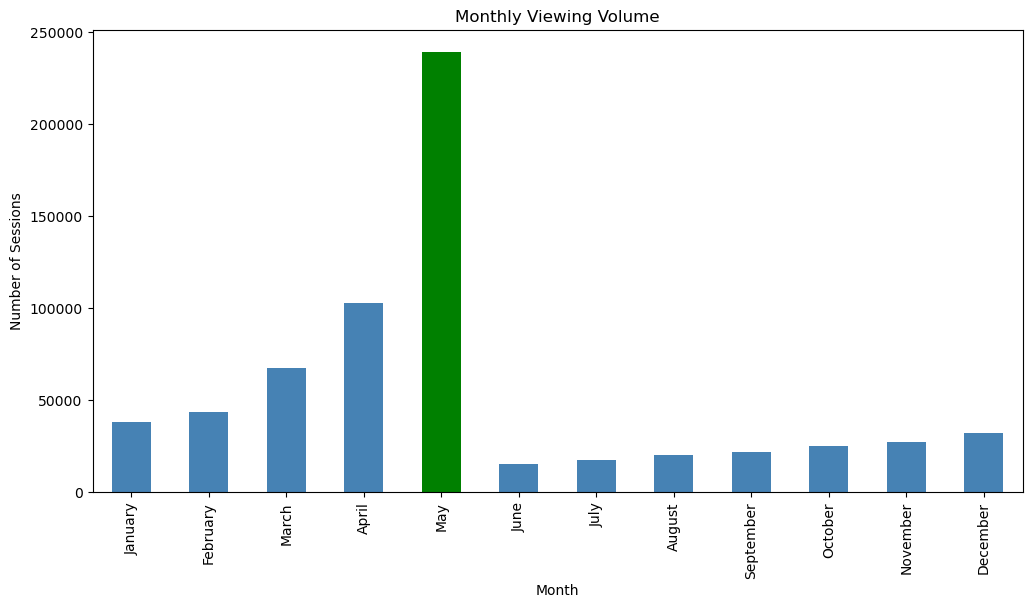

In [27]:
watch_history["month"] = watch_history["watch_date"].dt.month_name()
monthly_viewing_volume = watch_history.groupby("month")["watch_id"].count()

month_order = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]
monthly_viewing_volume = monthly_viewing_volume.reindex(month_order)

# Identify the busiest month
busiest_month = monthly_viewing_volume.idxmax()
bar_colors = ["green" if month == busiest_month else "steelblue" for month in monthly_viewing_volume.index]

monthly_viewing_volume.plot(kind="bar",figsize=(12,6), color=bar_colors)   
plt.title("Monthly Viewing Volume")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.savefig("Chart1_Monthly_Viewing_Volume.png", dpi=300, bbox_inches="tight")

## Observation

- Viewing volume increased sharply from January through May, with **May recording the highest number of viewing sessions**.
- Viewing sessions declined significantly in June and remained relatively lower during the second half of the year.
- Overall, **May was the busiest month**, while **June had the lowest viewing volume**.

In [6]:
#Monthly watch hours trend — same as above but using watch_duration_min (converted to hours). Compare year-over-year.

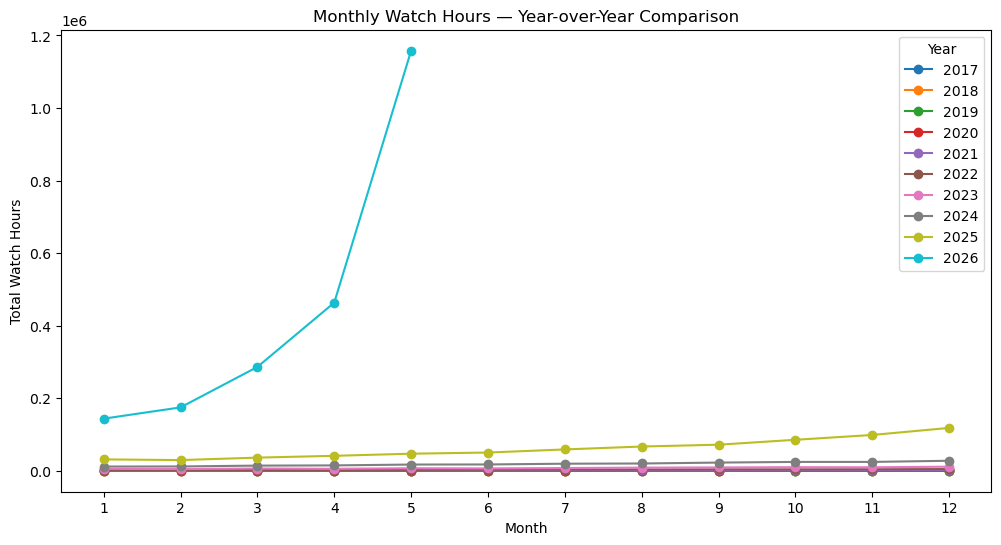

In [7]:
watch_history["year"] = watch_history["watch_date"].dt.year
watch_history["month"] = watch_history["watch_date"].dt.month
watch_history["watch_hours"] = watch_history["watch_duration_min"] / 60

monthly_watch_hours_yoy = watch_history.groupby(["month", "year"])["watch_hours"].sum().unstack()

monthly_watch_hours_yoy.plot(kind="line",figsize=(12, 6),marker="o")

plt.title("Monthly Watch Hours — Year-over-Year Comparison")
plt.xlabel("Month")
plt.ylabel("Total Watch Hours")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.savefig("Chart2_Monthly_Watch_Hours_YoY.png", dpi=300)

## Observation

- Watch hours show a strong increase during the first few months of the year, with **2026 showing the highest viewing activity**, particularly from March to May.
- **2025 also shows a steady upward trend** throughout the year, while earlier years have comparatively lower watch-hour levels.
- Overall, the YoY comparison indicates a **significant increase in viewing activity in recent years**.

In [8]:
#Genre-wise watch-hours share — a pie or horizontal bar chart. Which genre earns the most watch time?

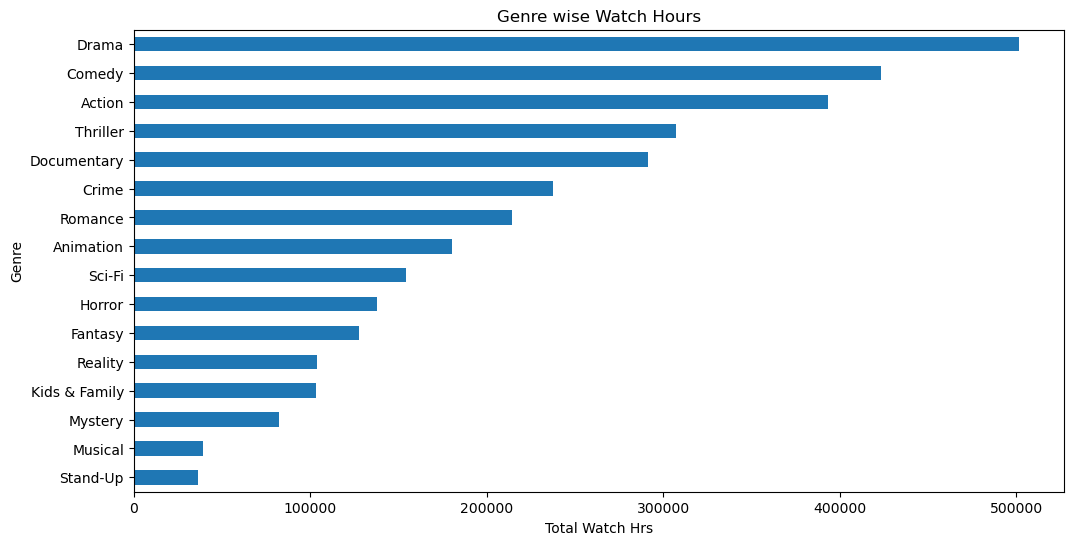

In [9]:
genre_wise_watch_hours = titles.groupby("primary_genre")["total_watch_hours"].sum()
genre_wise_watch_hours = genre_wise_watch_hours.sort_values(ascending=True)

genre_wise_watch_hours.plot(kind="barh",figsize=(12,6))   
plt.title("Genre wise Watch Hours")
plt.xlabel("Total Watch Hrs")
plt.ylabel("Genre")
plt.savefig("Chart3_Genre_Wise_Watch_Hours.png", dpi=300)

### Observation

- **Drama** has the highest total watch hours, making it the most-watched genre.
- **Comedy** and **Action** follow Drama with relatively high watch-time.
- **Stand-Up** and **Musical** have the lowest total watch hours among the genres.

In [10]:
#Content type split — a donut chart showing the share of hours for Movies vs. TV Shows.

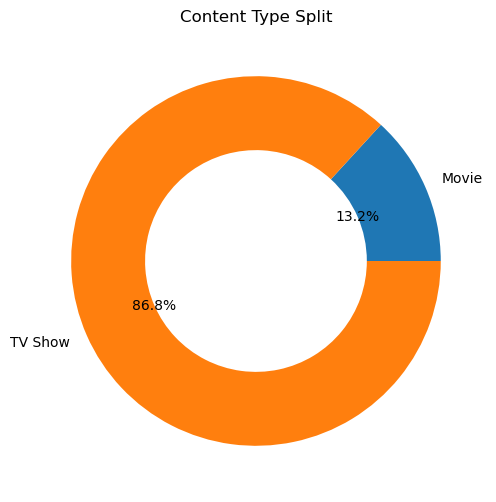

In [11]:
titles["content_duration_hrs"] = titles["content_duration_min"] / 60
content_type_split_hours = titles.groupby("type")["content_duration_hrs"].sum()
content_type_split_hours.plot(kind="pie", autopct="%1.1f%%", wedgeprops={"width":0.4}, figsize=(6,6)) 

plt.title("Content Type Split")
plt.ylabel("")
plt.savefig("Chart4_Content_type_split.png", dpi=300)

### Observation

- TV Shows account for a larger share **86.8%** of the total content hours compared with Movies.
- Movies contribute a smaller share **13.2%** of the overall available content duration.
- This indicates that StreamFlix has a greater volume of TV Show content in terms of total available hours.

In [12]:
#Top 10 countries by watch hours — a horizontal bar chart.

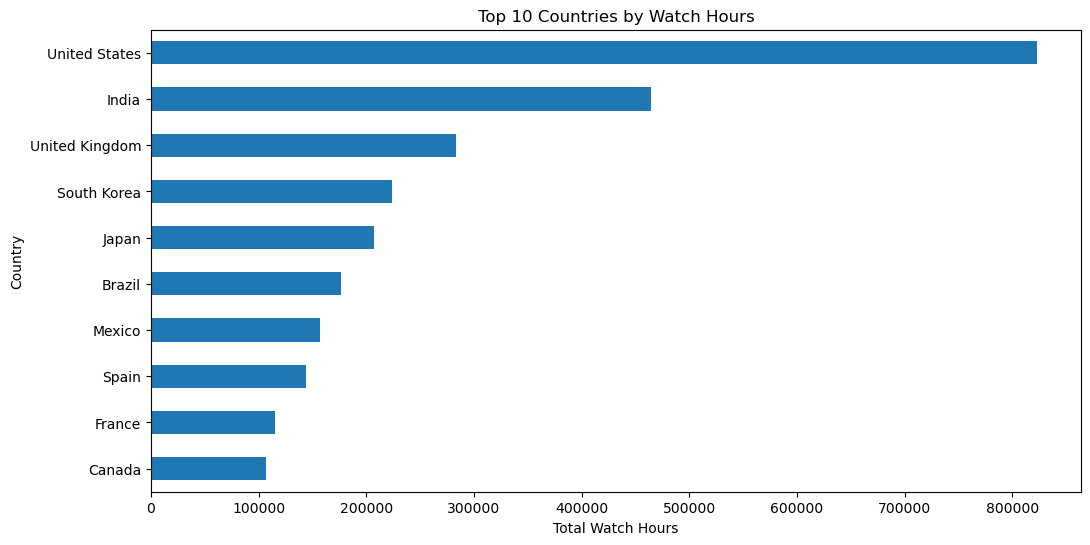

In [13]:
country_watch_hours = titles.groupby("country")["total_watch_hours"].sum()

Top10_country = country_watch_hours.sort_values(ascending=False).head(10)
Top10_country_sorted = Top10_country.sort_values(ascending=True)

Top10_country_sorted.plot(kind="barh", figsize=(12,6))

plt.title("Top 10 Countries by Watch Hours")
plt.xlabel("Total Watch Hours")
plt.ylabel("Country")
plt.savefig("Chart5_Top_10_Countries_by_Total_Watch_Hrs.png", dpi=300)

### Observation

- The **United States** has the highest total watch hours, followed by **India** and the **United Kingdom**.
- There is a significant gap between the United States and the other countries, indicating much higher content consumption from the US market.
- South Korea, Japan, Brazil, Mexico, Spain, France, and Canada make up the remaining top 10 countries by watch hours.

In [14]:
#Subscriber plan distribution — a pie chart. How many Basic vs. Standard vs. Premium subscribers?

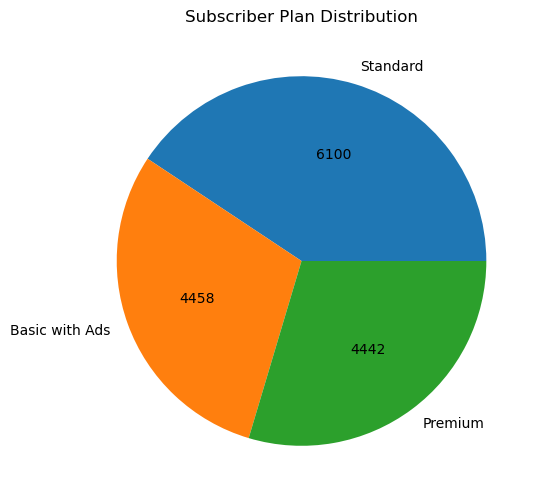

In [15]:
subscriber_plan_dist = subscribers["plan_type"].value_counts()
subscriber_plan_dist.plot(kind="pie",autopct=lambda p: f"{p * subscriber_plan_dist.sum() / 100:.0f}",figsize=(6,6))

plt.title("Subscriber Plan Distribution")
plt.ylabel("")
plt.savefig("Chart6_Subscriber_Plan_Distribution.png", dpi=300)

### Observation

- Standard is the most popular subscriber plan with **6,100 subscribers**.
- Basic with Ads has **4,458 subscribers**, while Premium has **4,442 subscribers**.
- Standard therefore has the largest subscriber base, while Basic with Ads and Premium have almost equal adoption.

In [16]:
#Device usage — a bar chart showing which devices people watch on most.

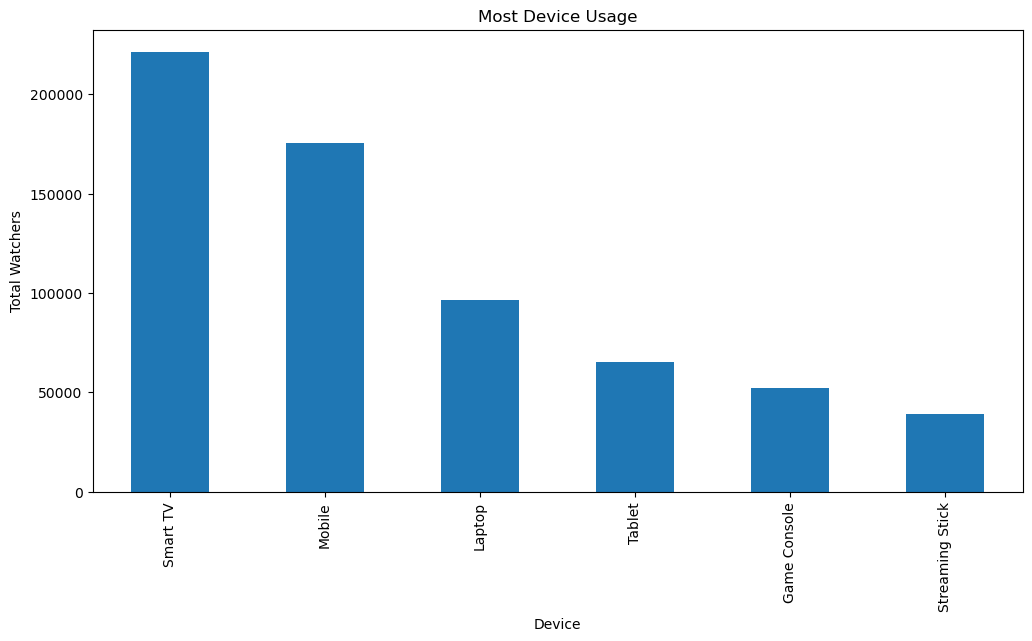

In [26]:
most_device_usage = watch_history.groupby("device")["watch_id"].count()
most_device_usage_sorted = most_device_usage.sort_values(ascending = False)

most_device_usage_sorted.plot(kind="bar",figsize=(12,6))   
plt.title("Most Device Usage")
plt.xlabel("Device")
plt.ylabel("Total Watchers")
plt.savefig("Chart7_Most_Device_Usage.png", dpi=300, bbox_inches="tight")

### Observation

- **Smart TV** is the most commonly used device, followed by **Mobile**.
- Laptop, Tablet, Game Console, and Streaming Stick have progressively lower usage.
- This indicates that viewing is dominated by Smart TV and Mobile devices.

In [ ]:
#Age distribution of subscribers — a histogram. Which age group watches most?

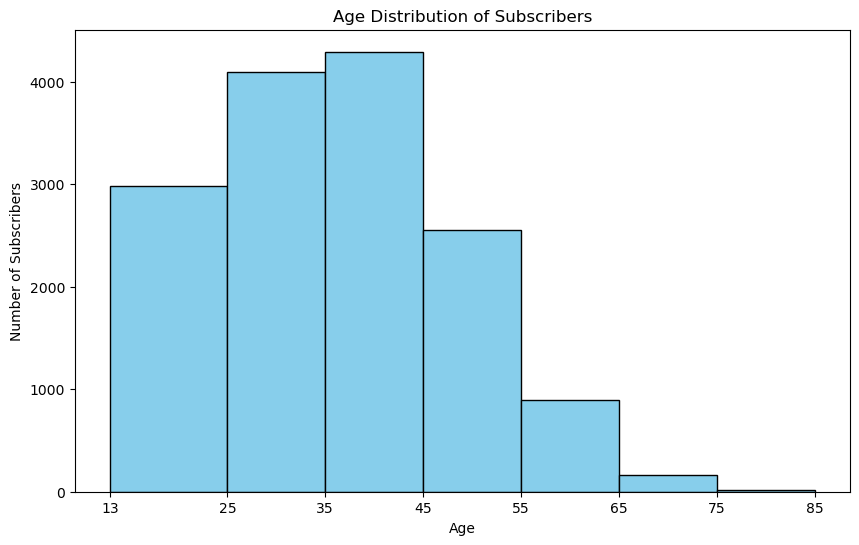

In [24]:
subscribers["age"].plot(kind="hist", bins=[13,25,35,45,55,65,75,85], figsize=(10,6), color="skyblue", edgecolor="black")

plt.xticks([13,25,35,45,55,65,75,85])
plt.title("Age Distribution of Subscribers")
plt.xlabel("Age")
plt.ylabel("Number of Subscribers")

plt.savefig("Chart8_Age_Distribution_of_Subscribers.png", dpi=300)

### Observation

- The **35–45 age group** has the highest number of subscribers.
- The **25–35 age group** is the next largest group, indicating that most subscribers are between **25 and 45 years** old.
- Subscriber count decreases noticeably for age groups above 45.

In [25]:
#Completion rate by genre — a bar chart. Which genres get finished?

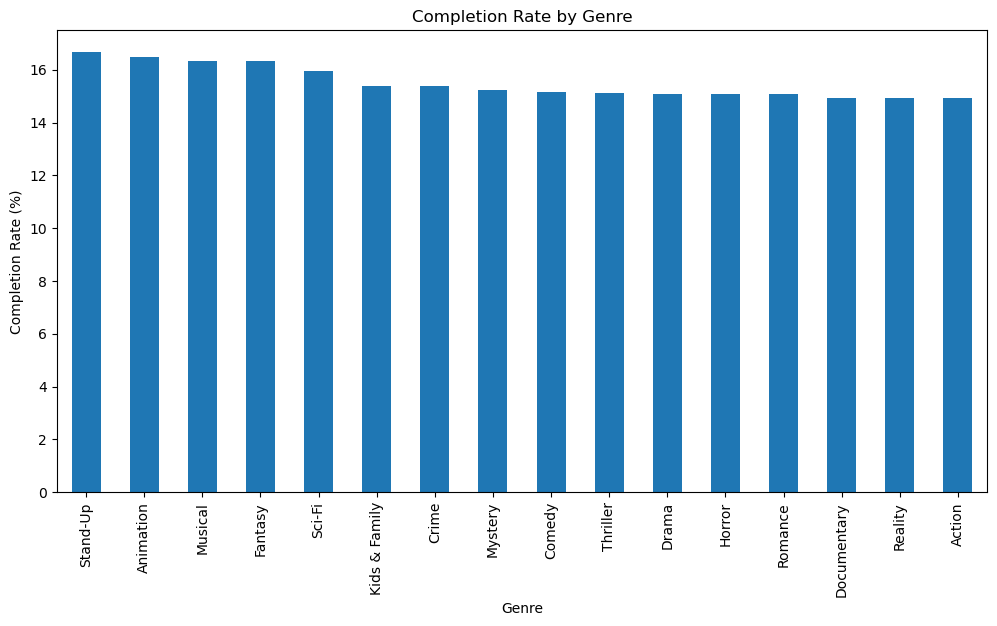

In [38]:
watch_genre = pd.merge(titles, watch_history,on="title_id")

completion_by_genre = watch_genre.groupby("primary_genre")["completed"].mean()*100
completion_by_genre_sorted = completion_by_genre.sort_values(ascending=False)
completion_by_genre_sorted.plot(kind="bar", figsize=(12,6))

plt.title("Completion Rate by Genre")
plt.xlabel("Genre")
plt.ylabel("Completion Rate (%)")
plt.savefig("Chart9_Completion_Rate_by_Genre.png", dpi=300, bbox_inches="tight")

### Observation

- **Stand-Up** has the highest completion rate, followed closely by **Animation, Musical, and Fantasy**.
- **Action** has the lowest completion rate, followed by **Reality and Documentary**.
- Overall, completion rates are relatively close across genres, with only a small difference between the highest and lowest genres.

In [39]:
#Review sentiment breakdown — a bar chart of Positive / Neutral / Negative review counts.

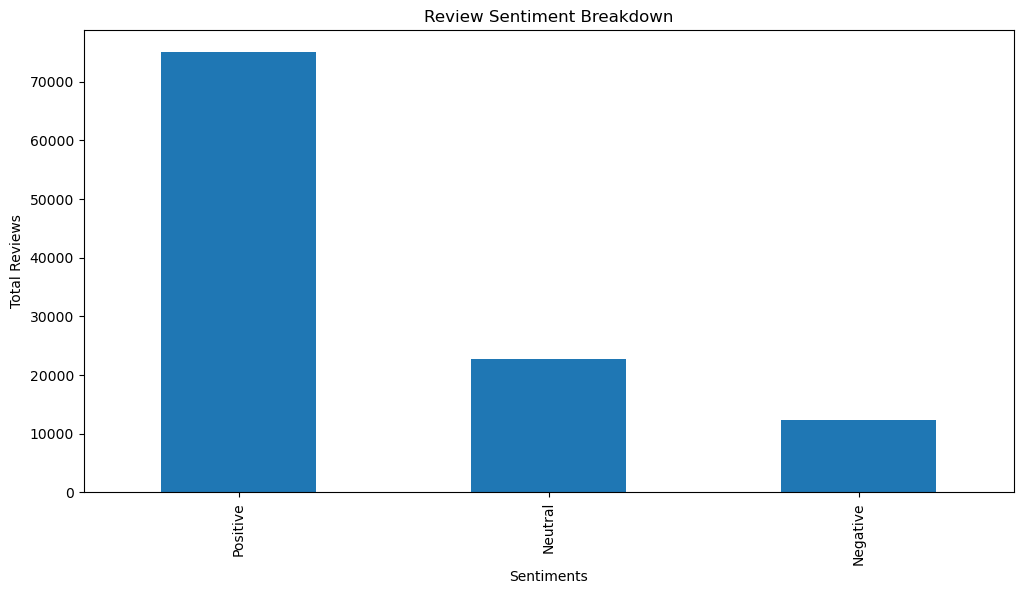

In [40]:
review_sentiment_breakdown = reviews.groupby("sentiment")["review_id"].count()
review_sentiment_breakdown_sorted = review_sentiment_breakdown.sort_values(ascending = False)

review_sentiment_breakdown_sorted.plot(kind="bar",figsize=(12,6))   
plt.title("Review Sentiment Breakdown")
plt.xlabel("Sentiments")
plt.ylabel("Total Reviews")
plt.savefig("Chart10_Review_Sentiment_Breakdown.png", dpi=300, bbox_inches="tight")

### Observation

- **Positive reviews** are the highest, followed by **Neutral reviews**.
- **Negative reviews** are the lowest, indicating that the overall review sentiment is predominantly positive.
- This suggests generally favorable customer feedback toward the content/service.